BFS Optimal Path: ['CliftonBeach', 'Saddar', 'Gulshan', 'TariqRoad', 'LuckyOneMall'] Duration: 71
DFS Optimal Path: ['CliftonBeach', 'Saddar', 'Gulshan', 'TariqRoad', 'LuckyOneMall'] Duration: 71


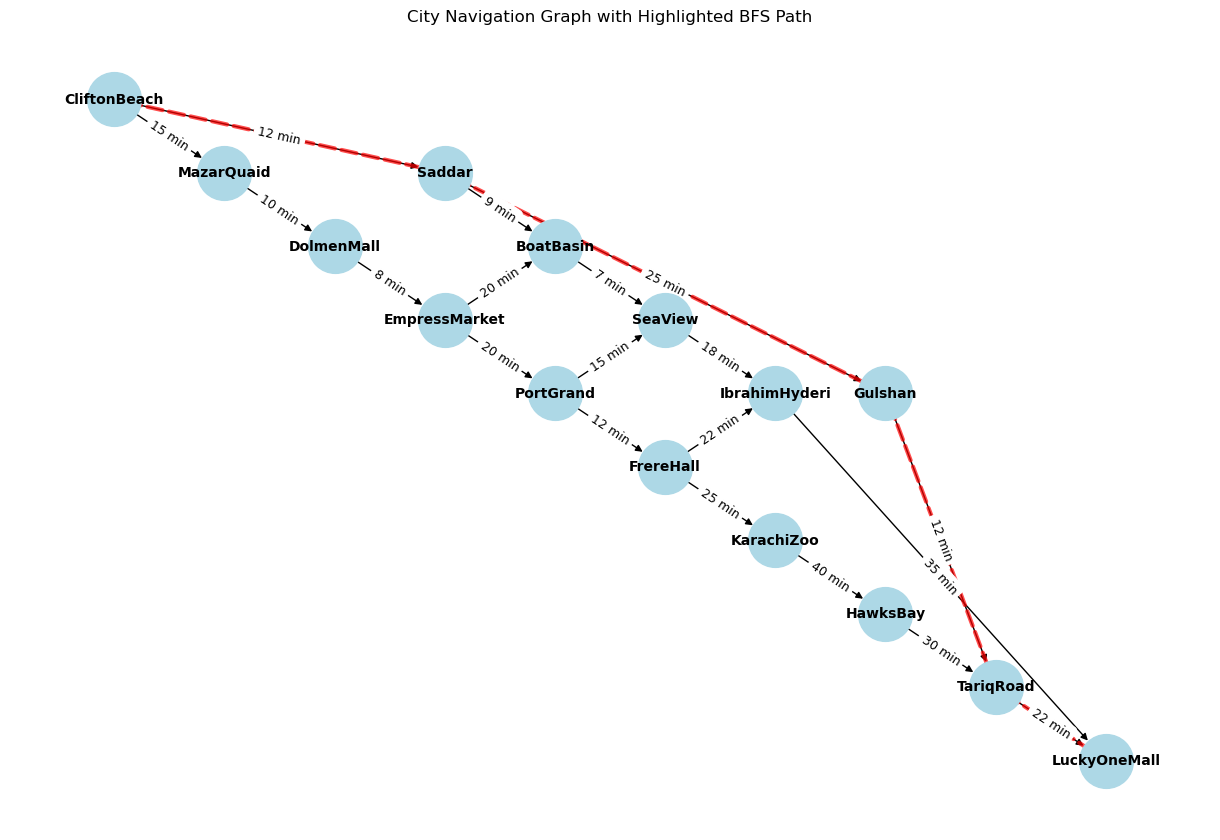

In [7]:
import networkx as nx
import matplotlib.pyplot as plt

city_graph = nx.DiGraph()

coordinates = {
    "CliftonBeach": (0, 10),
    "MazarQuaid": (1, 9),
    "DolmenMall": (2, 8),
    "EmpressMarket": (3, 7),
    "PortGrand": (4, 6),
    "FrereHall": (5, 5),
    "KarachiZoo": (6, 4),
    "HawksBay": (7, 3),
    "TariqRoad": (8, 2),
    "LuckyOneMall": (9, 1),
    "Saddar": (3, 9),
    "BoatBasin": (4, 8),
    "SeaView": (5, 7),
    "IbrahimHyderi": (6, 6),
    "Gulshan": (7, 6),
}

connections = [
    ("CliftonBeach", "MazarQuaid", {"distance": 5.5, "duration": 15, "traffic": 6}),
    ("MazarQuaid", "DolmenMall", {"distance": 4.0, "duration": 10, "traffic": 5}),
    ("DolmenMall", "EmpressMarket", {"distance": 3.5, "duration": 8, "traffic": 4}),
    ("EmpressMarket", "PortGrand", {"distance": 6.0, "duration": 20, "traffic": 7}),
    ("PortGrand", "FrereHall", {"distance": 4.2, "duration": 12, "traffic": 5}),
    ("FrereHall", "KarachiZoo", {"distance": 7.5, "duration": 25, "traffic": 8}),
    ("KarachiZoo", "HawksBay", {"distance": 12.0, "duration": 40, "traffic": 9}),
    ("HawksBay", "TariqRoad", {"distance": 10.5, "duration": 30, "traffic": 7}),
    ("TariqRoad", "LuckyOneMall", {"distance": 8.5, "duration": 22, "traffic": 6}),
    ("CliftonBeach", "Saddar", {"distance": 5.0, "duration": 12, "traffic": 5}),
    ("Saddar", "BoatBasin", {"distance": 3.0, "duration": 9, "traffic": 4}),
    ("BoatBasin", "SeaView", {"distance": 2.5, "duration": 7, "traffic": 3}),
    ("SeaView", "IbrahimHyderi", {"distance": 6.5, "duration": 18, "traffic": 6}),
    ("IbrahimHyderi", "LuckyOneMall", {"distance": 15.0, "duration": 35, "traffic": 7}),
    ("Saddar", "Gulshan", {"distance": 9.5, "duration": 25, "traffic": 8}),
    ("Gulshan", "TariqRoad", {"distance": 4.5, "duration": 12, "traffic": 4}),
    ("EmpressMarket", "BoatBasin", {"distance": 7.0, "duration": 20, "traffic": 6}),
    ("PortGrand", "SeaView", {"distance": 5.5, "duration": 15, "traffic": 5}),
    ("FrereHall", "IbrahimHyderi", {"distance": 8.0, "duration": 22, "traffic": 6}),
]

city_graph.add_nodes_from(coordinates.keys())
city_graph.add_edges_from((source, target, data) for source, target, data in connections)

def shortest_route_bfs(graph, start, goal, attribute="duration"):
    visited = set()
    queue = [(start, [start], 0)]
    best_path = None
    best_cost = float("inf")

    while queue:
        current, route, total_cost = queue.pop(0)

        if current in visited:
            continue

        visited.add(current)

        if current == goal and total_cost < best_cost:
            best_path = route
            best_cost = total_cost
            continue

        for neighbor in graph.neighbors(current):
            edge_info = graph[current][neighbor]
            new_cost = total_cost + edge_info[attribute]
            queue.append((neighbor, route + [neighbor], new_cost))

    return best_path, best_cost

def shortest_route_dfs(graph, start, goal, attribute="duration"):
    visited = set()
    stack = [(start, [start], 0)]
    best_path = None
    best_cost = float("inf")

    while stack:
        current, route, total_cost = stack.pop()

        if current in visited:
            continue

        visited.add(current)

        if current == goal and total_cost < best_cost:
            best_path = route
            best_cost = total_cost
            continue

        for neighbor in graph.neighbors(current):
            edge_info = graph[current][neighbor]
            new_cost = total_cost + edge_info[attribute]
            stack.append((neighbor, route + [neighbor], new_cost))

    return best_path, best_cost

def highlight_path(graph, path, pos):
    edges = list(zip(path, path[1:]))
    nx.draw_networkx_edges(
        graph,
        pos,
        edgelist=edges,
        edge_color="red",
        width=3,
        alpha=0.7,
        style="dashed",
    )

bfs_path, bfs_duration = shortest_route_bfs(city_graph, "CliftonBeach", "LuckyOneMall", attribute="duration")
dfs_path, dfs_duration = shortest_route_dfs(city_graph, "CliftonBeach", "LuckyOneMall", attribute="duration")

print("BFS Optimal Path:", bfs_path, "Duration:", bfs_duration)
print("DFS Optimal Path:", dfs_path, "Duration:", dfs_duration)

plt.figure(figsize=(12, 8))
nx.draw(
    city_graph,
    pos=coordinates,
    with_labels=True,
    node_color="lightblue",
    node_size=1500,
    font_size=10,
    font_weight="bold",
    edge_color="black",
)

highlight_path(city_graph, bfs_path, coordinates)

edge_labels = {(source, target): f"{data['duration']} min" for source, target, data in connections}
nx.draw_networkx_edge_labels(city_graph, pos=coordinates, edge_labels=edge_labels, font_size=9)

plt.title("City Navigation Graph with Highlighted BFS Path")
plt.show()
